Original train shape: (12774667, 4), [12764957     9710]
SMOTE train shape: (15317948, 4), [12764957  2552991]
Use /var/folders/wn/xdcqjsfn1q37gf381p3xc6500000gn/T/tmpafvqjqpv as temporary training directory
Reading training dataset...


[WARNING 25-12-07 18:53:32.2265 PST gradient_boosted_trees.cc:1840] "goss_alpha" set but "sampling_method" not equal to "GOSS".
[WARNING 25-12-07 18:53:32.2287 PST gradient_boosted_trees.cc:1851] "goss_beta" set but "sampling_method" not equal to "GOSS".
[WARNING 25-12-07 18:53:32.2288 PST gradient_boosted_trees.cc:1865] "selective_gradient_boosting_ratio" set but "sampling_method" not equal to "SELGB".


Training dataset read in 0:01:24.676152. Found 15317948 examples.
Training model...
Model trained in 0:23:16.053435
Compiling model...


[INFO 25-12-07 19:18:12.9263 PST kernel.cc:1233] Loading model from path /var/folders/wn/xdcqjsfn1q37gf381p3xc6500000gn/T/tmpafvqjqpv/model/ with prefix 235e978b881b4173
[INFO 25-12-07 19:18:12.9985 PST decision_forest.cc:734] Model loaded with 101 root(s), 25185 node(s), and 4 input feature(s).
[INFO 25-12-07 19:18:12.9986 PST abstract_model.cc:1344] Engine "GradientBoostedTreesOptPred" built
[INFO 25-12-07 19:18:12.9986 PST kernel.cc:1061] Use fast generic engine


Model compiled.
VALIDATION RESULTS
2738/2738 [==============================] - 18s 6ms/step
-------------------------
Classification Report
-------------------------
              precision    recall  f1-score   support

           0       1.00      0.50      0.67   2735348
           1       0.00      0.91      0.00      2081

    accuracy                           0.50   2737429
   macro avg       0.50      0.71      0.34   2737429
weighted avg       1.00      0.50      0.67   2737429



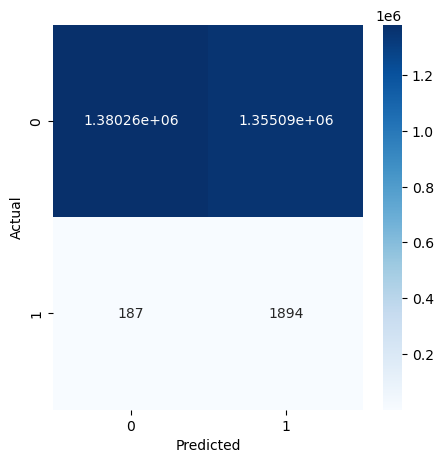

TEST RESULTS
2738/2738 [==============================] - 20s 7ms/step
-------------------------
Classification Report
-------------------------
              precision    recall  f1-score   support

           0       1.00      0.51      0.67   2735349
           1       0.00      0.90      0.00      2080

    accuracy                           0.51   2737429
   macro avg       0.50      0.70      0.34   2737429
weighted avg       1.00      0.51      0.67   2737429



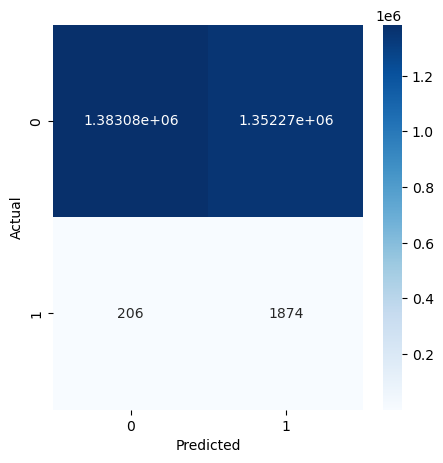

In [3]:
import numpy as np
import pandas as pd
import tensorflow as tf
import tensorflow_decision_forests as tfdf
from sklearn.metrics import confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils.class_weight import compute_class_weight

MODIS_FIRMS_TRAIN_VAL_TEST_DATASET = '../data/processed/modis_firms_train_val_test_dataset.npz'

# -----------------------------
# 1. Load Data
# -----------------------------
data = np.load(MODIS_FIRMS_TRAIN_VAL_TEST_DATASET)

X_train = data["X_train"]
y_train = data["y_train"]
X_val = data["X_val"]
y_val = data["y_val"]
X_test = data["X_test"]
y_test = data["y_test"]

feature_names = ["NDVI", "EVI", "LST_Day", "LST_Night"]

# -----------------------------
# 2. Apply SMOTE to training data
# -----------------------------
sm = SMOTE(sampling_strategy=0.2, random_state=42)  # fire class becomes 20% of training set
X_train_bal, y_train_bal = sm.fit_resample(X_train, y_train)

print(f"Original train shape: {X_train.shape}, {np.bincount(y_train)}")
print(f"SMOTE train shape: {X_train_bal.shape}, {np.bincount(y_train_bal)}")

# -----------------------------
# 3. Convert to DataFrame for TF-DF
# -----------------------------
train_df = pd.DataFrame(X_train_bal, columns=feature_names)
train_df["label"] = y_train_bal

val_df = pd.DataFrame(X_val, columns=feature_names)
val_df["label"] = y_val

test_df = pd.DataFrame(X_test, columns=feature_names)
test_df["label"] = y_test

# -----------------------------
# 4. Compute class weights
# -----------------------------
classes = np.array([0,1])
cw = compute_class_weight(class_weight="balanced", classes=classes, y=y_train_bal)
class_weights = {0: cw[0], 1: cw[1]}
print(f"class_weights: {class_weights}")

# Map weights to "w" column (must exist for TF-DF)
train_df["w"] = train_df["label"].map(class_weights)
val_df["w"] = val_df["label"].map(class_weights)
test_df["w"] = test_df["label"].map(class_weights)

# -----------------------------
# 5. Convert to TF-DF Datasets
# -----------------------------
train_ds = tfdf.keras.pd_dataframe_to_tf_dataset(train_df, label="label", weight="w")
val_ds   = tfdf.keras.pd_dataframe_to_tf_dataset(val_df, label="label", weight="w")
test_ds  = tfdf.keras.pd_dataframe_to_tf_dataset(test_df, label="label", weight="w")

# -----------------------------
# 6. Build Gradient Boosted Trees model
# -----------------------------
model = tfdf.keras.GradientBoostedTreesModel(
    loss="BINOMIAL_LOG_LIKELIHOOD",  # binary cross-entropy
    num_trees=500,
    max_depth=8
)

# Train the model
model.fit(train_ds)

# -----------------------------
# 7. Evaluation function
# -----------------------------
def evaluate_model(model, dataset, y_true, threshold=0.3):
    # TF-DF predicts probabilities for class 1 by default with GBT
    y_prob = model.predict(dataset).reshape(-1)
    y_pred = (y_prob >= threshold).astype(int)
    
    cnf_matrix = confusion_matrix(y_true, y_pred)
    print("-"*25)
    print("Classification Report")
    print("-"*25)
    print(classification_report(y_true, y_pred))
    
    plt.figure(figsize=(5,5))
    sns.heatmap(cnf_matrix, annot=True, fmt="g", cmap=plt.cm.Blues)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()
    
    return y_pred

# -----------------------------
# 8. Evaluate on Validation and Test sets
# -----------------------------
print("VALIDATION RESULTS")
y_val_pred = evaluate_model(model, val_ds, y_val, threshold=0.3)  # low threshold to catch more fires

print("TEST RESULTS")
y_test_pred = evaluate_model(model, test_ds, y_test, threshold=0.3)